In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import math
from matplotlib.ticker import ScalarFormatter
import flopy
from matplotlib.colors import ListedColormap
import matplotlib.patches as patches
import matplotlib.ticker as mticker
from matplotlib.ticker import FormatStrFormatter
from numpy.ma import count

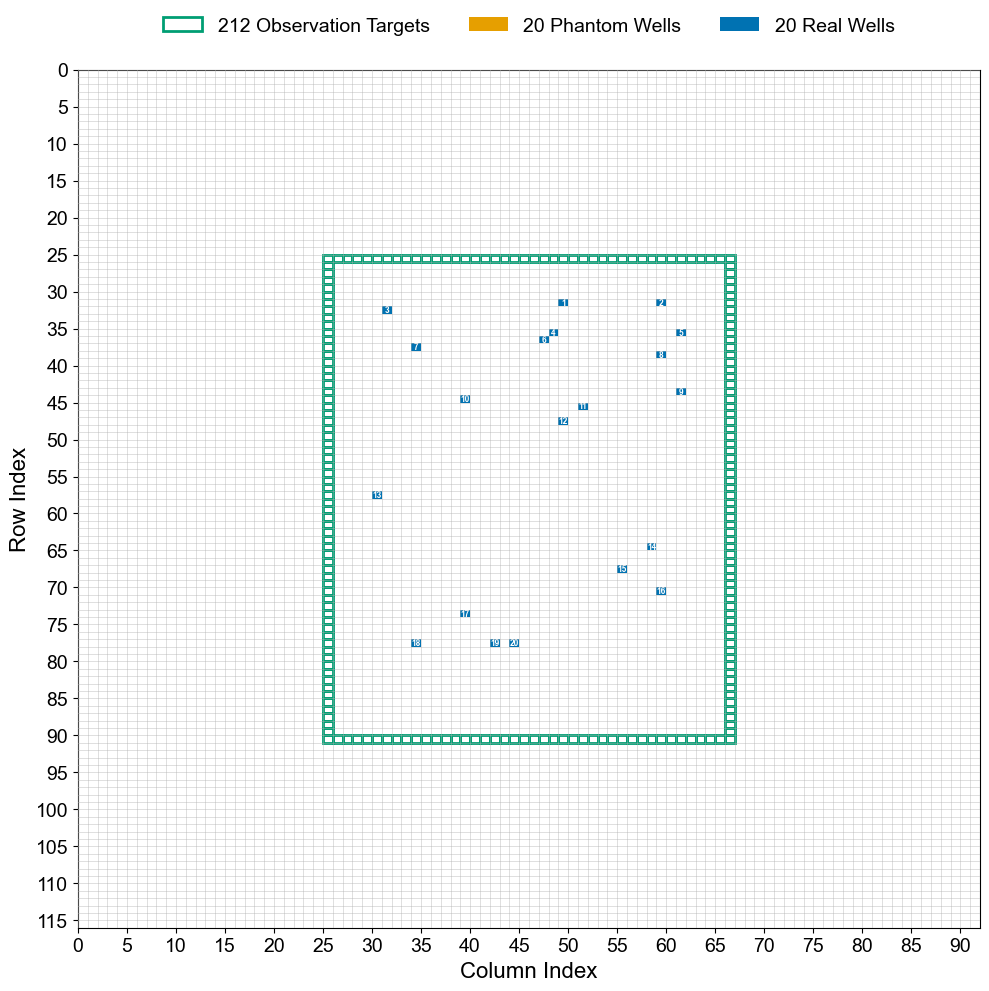

In [4]:
########################
### domain and wells ###
########################

size = 16

# load the real simulation to get grid dimensions
sim_real = flopy.mf6.MFSimulation.load(sim_ws=str(real_ws), verbosity_level=0)
gwf = sim_real.get_model("real")
nrow, ncol = gwf.dis.nrow.get_data(), gwf.dis.ncol.get_data()

# load Phantom simulations to get Phantom locations
phantom_coords = []
for folder in [f for f in os.listdir(sims_dir) if f.startswith("phantom_")]:
    try:
        p_sim = flopy.mf6.MFSimulation.load(sim_ws=str(sims_dir/folder), verbosity_level=0, load_only=['wel'])
        gwf_p = p_sim.get_model()
        spd_dict = gwf_p.wel.stress_period_data.get_data()
        
        # target stress period 0 explicitly
        if 0 in spd_dict:
            for entry in spd_dict[0]:  # loop over the recarray records, not keys
                # exrtact elements [1] and [2] from the (layer, row, col) tuple
                r_p = entry['cellid'][1]
                c_p = entry['cellid'][2]
                phantom_coords.append((r_p, c_p))
    except Exception as e:
        # print to catch other issues if they happen
        print(f"Error loading {folder}: {e}")
        continue

sorted_phantoms = sorted(list(set(phantom_coords)))

# get perimeter mask
perimeter_mask = np.zeros((nrow, ncol))
for r, c in set(phantom_coords):
    perimeter_mask[r, c] = 1

# get Real well locations
real_spd = gwf.wel.stress_period_data.get_data()[0]
real_mask = np.zeros((nrow, ncol))
for e in real_spd:
    r, c = e['cellid'][1], e['cellid'][2]
    real_mask[r, c] = 1

# re-generate compliance point cells
margin = int(margin_size)
r_start, r_end = margin, (nrow - margin) - 1
c_start, c_end = margin, (ncol - margin) - 1
cp_cells = []

# top and bottom perimeter cells
for c in range(c_start, c_end + 1):
    cp_cells.extend([(r_start, c), (r_end, c)])

# left and right perimeter cells, excluding corners
for r in range(r_start + 1, r_end):
    cp_cells.extend([(r, c_start), (r, c_end)])

sorted_cp = sorted(list(set(cp_cells)))

# plot
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.set_facecolor('white')
ax.invert_yaxis()

# base map (empty, just to set extent and aspect)
mapview = flopy.plot.PlotMapView(model=gwf, ax=ax, extent=(0, ncol, 0, nrow))

# plot observation targets
for i, (r, c) in enumerate(sorted_cp):
    rect = patches.Rectangle(
        (c, r), 1, 1, 
        linewidth=2, 
        edgecolor="#009E73",
        facecolor='none',     
        zorder=3
    )
    ax.add_patch(rect)

# plot Phantom wells
for i, (r, c) in enumerate(sorted_phantoms):
    # visual centre of the cell using native row positions
    x_pos = c + 0.5
    y_pos = r + 0.5
    
    rect = patches.Rectangle((c, r), 1, 1, 
                             linewidth=0, facecolor='#E69F00', zorder=2)
    ax.add_patch(rect)
    
    # sequential number label
    ax.text(x_pos, y_pos, str(i + 1), 
            color='white', fontsize=size-10, fontweight='bold',
            ha='center', va='center', zorder=4)

# Real wells
real_spd = gwf.wel.stress_period_data.get_data()[0]
for entry in real_spd:
    _, r_w, c_w = entry['cellid']
    rect = patches.Rectangle((c_w, r_w), 1, 1, linewidth=0, facecolor='#0072B2', zorder=3)
    ax.add_patch(rect)

# grid lines
grid_cfg = {'color': "#B3B3B3", 'lw': 0.5, 'alpha': 0.6, 'zorder': 100} 
for x in range(ncol + 1):
    ax.plot([x, x], [0, nrow], **grid_cfg)
for y in range(nrow + 1):
    ax.plot([0, ncol], [y, y], **grid_cfg)

# labels
ax.set_xlabel("Column Index", fontsize=size)
ax.set_ylabel("Row Index", fontsize=size)

# ticks - simple and un-flipped because invert_yaxis() handles it perfectly
ax.set_xticks(np.arange(0, ncol + 1, 5))
ax.set_yticks(np.arange(0, nrow + 1, 5))

# tick parameters
ax.tick_params(axis='both', which='major', labelsize=size-2)

ax.set_xlim(0, ncol)
# Note: When y-axis is inverted, set_ylim changes order: (top_value, bottom_value)
ax.set_ylim(nrow, 0)

# legend
legend_elements = [
    patches.Patch(facecolor='none', edgecolor="#009E73", linewidth=2, label=f'{len(sorted_cp)} Observation Targets'),
    patches.Patch(facecolor='#E69F00', edgecolor='none', label=f'{len(sorted_phantoms)} Phantom Wells'),
    patches.Patch(facecolor='#0072B2', edgecolor='none', label=f'{len(real_spd)} Real Wells')
]

ax.legend(
    handles=legend_elements, 
    loc='lower center', 
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,            
    facecolor='white', 
    edgecolor='none',   
    framealpha=1, 
    fontsize=size-2
)

plt.tight_layout()
plt.savefig(f"{root}_incdd_domain.svg", dpi=300, bbox_inches='tight')
plt.show()

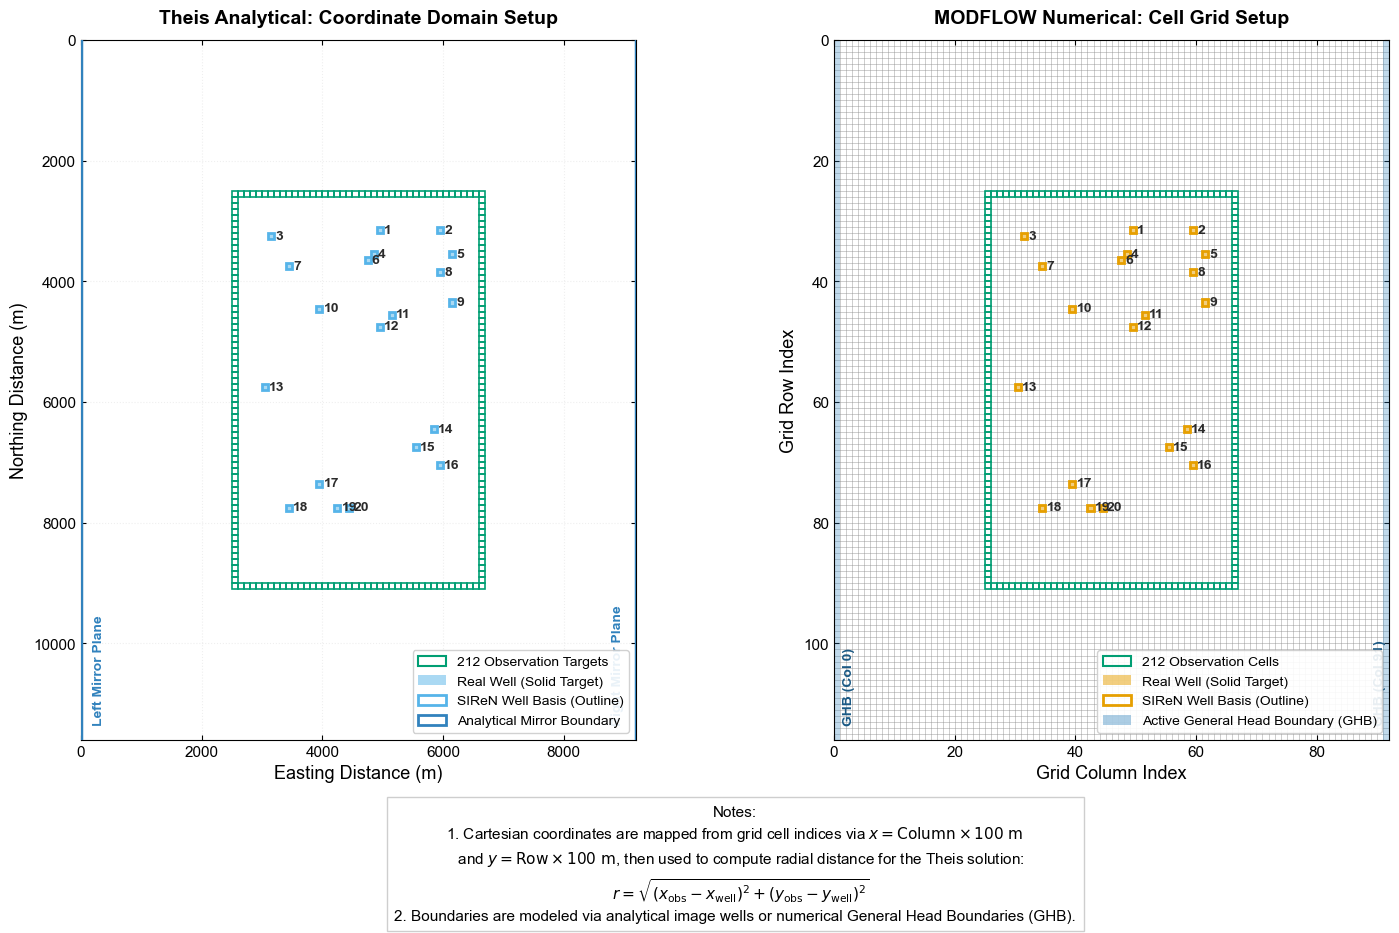

Saved to: C:\Python\Personal\kfm-ms\codes\figures\side_by_side_domain_setup.svg


In [45]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as patches
from pathlib import Path

# =====================================================================
# 1. CORE PARAMETERS & PATH INITIALIZATION
# =====================================================================
num_root = "numbasis"
ana_root = "anabasis"

# Grid configuration definitions
nrow, ncol = 116, 92
cell_dim = 100.0  # meters per grid cell block
margin = 25

results_path = Path("..") / "results"
figures_output_path = Path(r"C:\Python\Personal\kfm-ms\codes\figures")
figures_output_path.mkdir(parents=True, exist_ok=True)

# Generate identical perimeter compliance point coordinate arrays
r_start, r_end = margin, (nrow - margin) - 1
c_start, c_end = margin, (ncol - margin) - 1
cp_cells = []
for c in range(c_start, c_end + 1):
    cp_cells.extend([(r_start, c), (r_end, c)])
for r in range(r_start + 1, r_end):
    cp_cells.extend([(r, c_start), (r, c_end)])
sorted_cp = sorted(list(set(cp_cells)))

# Load the master truth spreadsheet to extract spatial tracking configurations safely
try:
    master_truth = pd.read_csv(results_path / "real" / "master_truth.csv")
    well_positions = master_truth[['r', 'c']].drop_duplicates().values.tolist()
except FileNotFoundError:
    import random
    random.seed(42)
    inner_rows = range(margin + 5, r_end - 5 + 1)
    inner_coords = [(r, c) for r in inner_rows for c in range(margin + 5, c_end - 5 + 1)]
    well_positions = random.sample(inner_coords, 20)

# Sort well positions geographically to keep numbering consistency neat
well_positions = sorted(well_positions, key=lambda x: (x[0], x[1]))

# =====================================================================
# 2. CANVAS INITIALIZATION (SIDE-BY-SIDE COMPACT REPORT LAYOUT)
# =====================================================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans']

# Layout optimized for horizontal reporting without wasting vertical space
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10))
plt.subplots_adjust(wspace=0.15, bottom=0.22, top=0.92, left=0.06, right=0.94)

size = 14
grid_cfg = {'color': "#8c8c8c", 'lw': 0.5, 'alpha': 0.6, 'zorder': 1}

# =====================================================================
# PANEL 1: THEIS ANALYTICAL MODEL SPACE (LEFT PANEL - METERS)
# =====================================================================
ax1.set_facecolor('white')
lx_m, ly_m = ncol * cell_dim, nrow * cell_dim

# Plot Analytical Observation Point Vectors
for r, c in sorted_cp:
    rect = patches.Rectangle(
        (c * cell_dim, r * cell_dim), cell_dim, cell_dim, 
        linewidth=1.2, edgecolor="#009E73", facecolor='none', zorder=3
    )
    ax1.add_patch(rect)

# Plot Wells (Analytical Layer)
for i, (r, c) in enumerate(well_positions):
    # Real Well: Solid Fill
    rect_real = patches.Rectangle(
        (c * cell_dim, r * cell_dim), cell_dim, cell_dim, 
        linewidth=0, facecolor='#56B4E9', alpha=0.5, zorder=2
    )
    ax1.add_patch(rect_real)
    
    # SIReN Well: Co-located Outline (thickened line to pop visually)
    rect_siren = patches.Rectangle(
        (c * cell_dim, r * cell_dim), cell_dim, cell_dim, 
        linewidth=2.0, edgecolor='#56B4E9', facecolor='none', zorder=3
    )
    ax1.add_patch(rect_siren)
    
    # Text Placement: Fixed offset just to the right of the cell edge, removing arrows
    x_text = (c + 1.2) * cell_dim
    y_text = (r + 0.5) * cell_dim
    ax1.text(
        x_text, y_text, str(i + 1), 
        fontsize=size-4, fontweight='bold', color='#2b2b2b',
        va='center', ha='left', zorder=5
    )

# Visualizing the Analytical Constant-Head Mirror Boundaries
ax1.axvline(0, color='#3182bd', lw=2.5, linestyle='-', zorder=4)
ax1.axvline(lx_m, color='#3182bd', lw=2.5, linestyle='-', zorder=4)
ax1.text(200, ly_m - 300, "Left Mirror Plane", color='#3182bd', fontsize=size-4, fontweight='bold', rotation=90)
ax1.text(lx_m - 400, ly_m - 300, "Right Mirror Plane", color='#3182bd', fontsize=size-4, fontweight='bold', rotation=90)

# Set exact tracking limits to clip white space while locking 1:1 scale
ax1.set_xlim(0, lx_m)
ax1.set_ylim(ly_m, 0)
ax1.set_aspect('equal', adjustable='box')

ax1.set_xlabel("Easting Distance (m)", fontsize=size-1)
ax1.set_ylabel("Northing Distance (m)", fontsize=size-1)
ax1.set_title("Theis Analytical: Coordinate Domain Setup", fontsize=size, pad=12, fontweight='bold')
ax1.tick_params(axis='both', which='major', labelsize=size-3, direction='in', top=True, right=True)
ax1.grid(True, alpha=0.2, linestyle=':')

leg_ana = [
    patches.Patch(facecolor='none', edgecolor="#009E73", linewidth=1.5, label=f'{len(sorted_cp)} Observation Targets'),
    patches.Patch(facecolor='#56B4E9', alpha=0.5, edgecolor='none', label='Real Well (Solid Target)'),
    patches.Patch(facecolor='none', edgecolor='#56B4E9', linewidth=2, label='SIReN Well Basis (Outline)'),
    patches.Patch(facecolor='none', edgecolor='#3182bd', linewidth=2, label='Analytical Mirror Boundary')
]
ax1.legend(handles=leg_ana, loc='lower right', ncol=1, facecolor='white', edgecolor='#cccccc', framealpha=0.9, fontsize=size-4)

# =====================================================================
# PANEL 2: MODFLOW NUMERICAL SPACE (RIGHT PANEL - DISCRETE CELLS)
# =====================================================================
ax2.set_facecolor('white')

# Plot Numerical Observation Points (Cell Slices)
for r, c in sorted_cp:
    rect = patches.Rectangle(
        (c, r), 1, 1, linewidth=1.2, edgecolor="#009E73", facecolor='none', zorder=3
    )
    ax2.add_patch(rect)

# Plot Wells (Numerical Layer)
for i, (r, c) in enumerate(well_positions):
    # Real Well: Solid Fill
    rect_real = patches.Rectangle(
        (c, r), 1, 1, 
        linewidth=0, facecolor='#E69F00', alpha=0.5, zorder=2
    )
    ax2.add_patch(rect_real)
    
    # SIReN Well: Co-located Outline
    rect_siren = patches.Rectangle(
        (c, r), 1, 1, 
        linewidth=2.0, edgecolor='#E69F00', facecolor='none', zorder=3
    )
    ax2.add_patch(rect_siren)
    
    # Text Placement: Fixed offset just to the right of the cell edge, removing arrows
    x_text = c + 1.2
    y_text = r + 0.5
    ax2.text(
        x_text, y_text, str(i + 1), 
        fontsize=size-4, fontweight='bold', color='#2b2b2b',
        va='center', ha='left', zorder=5
    )

# Shaded General Head Boundary (GHB) representations
rect_ghb_left = patches.Rectangle((0, 0), 1, nrow, facecolor='#3182bd', alpha=0.3, zorder=2)
rect_ghb_right = patches.Rectangle((ncol - 1, 0), 1, nrow, facecolor='#3182bd', alpha=0.3, zorder=2)
ax2.add_patch(rect_ghb_left)
ax2.add_patch(rect_ghb_right)
ax2.text(1.5, nrow - 3, "GHB (Col 0)", color='#1c5a85', fontsize=size-4, fontweight='bold', rotation=90)
ax2.text(ncol - 2.5, nrow - 3, "GHB (Col 91)", color='#1c5a85', fontsize=size-4, fontweight='bold', rotation=90)

# Full visible grid layout configuration
for x in range(ncol + 1):
    ax2.plot([x, x], [0, nrow], **grid_cfg)
for y in range(nrow + 1):
    ax2.plot([0, ncol], [y, y], **grid_cfg)

# Set exact tracking limits to clip white space while locking 1:1 scale
ax2.set_xlim(0, ncol)
ax2.set_ylim(nrow, 0)
ax2.set_aspect('equal', adjustable='box')

ax2.set_xlabel("Grid Column Index", fontsize=size-1)
ax2.set_ylabel("Grid Row Index", fontsize=size-1)
ax2.set_title("MODFLOW Numerical: Cell Grid Setup", fontsize=size, pad=12, fontweight='bold')
ax2.tick_params(axis='both', which='major', labelsize=size-3, direction='in', top=True, right=True)

leg_num = [
    patches.Patch(facecolor='none', edgecolor="#009E73", linewidth=1.5, label=f'{len(sorted_cp)} Observation Cells'),
    patches.Patch(facecolor='#E69F00', alpha=0.5, edgecolor='none', label='Real Well (Solid Target)'),
    patches.Patch(facecolor='none', edgecolor='#E69F00', linewidth=2, label='SIReN Well Basis (Outline)'),
    patches.Patch(facecolor='#3182bd', alpha=0.4, edgecolor='none', label='Active General Head Boundary (GHB)')
]
ax2.legend(handles=leg_num, loc='lower right', ncol=1, facecolor='white', edgecolor='#cccccc', framealpha=0.9, fontsize=size-4)

# =====================================================================
# 3. REPORT EXPLANATORY CAPTION FOOTER & SAVE
# =====================================================================
note_text = (
    "Notes:\n"
    "1. Cartesian coordinates are mapped from grid cell indices via $x = \\text{Column} \\times 100\\text{ m}$\n"
    "   and $y = \\text{Row} \\times 100\\text{ m}$, then used to compute radial distance for the Theis solution:\n"
    "   $r = \\sqrt{(x_{\\mathrm{obs}} - x_{\\mathrm{well}})^2 + (y_{\\mathrm{obs}} - y_{\\mathrm{well}})^2}$\n"
    "2. Boundaries are modeled via analytical image wells or numerical General Head Boundaries (GHB)."
)

fig.text(0.5, 0.04, note_text, ha='center', fontsize=size-3, fontweight='medium', linespacing=1.4,
         bbox=dict(facecolor='white', alpha=0.95, edgecolor='#cccccc', boxstyle='square,pad=0.5'))

save_name = figures_output_path / "side_by_side_domain_setup.svg"
plt.savefig(save_name, dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved to: {save_name}")

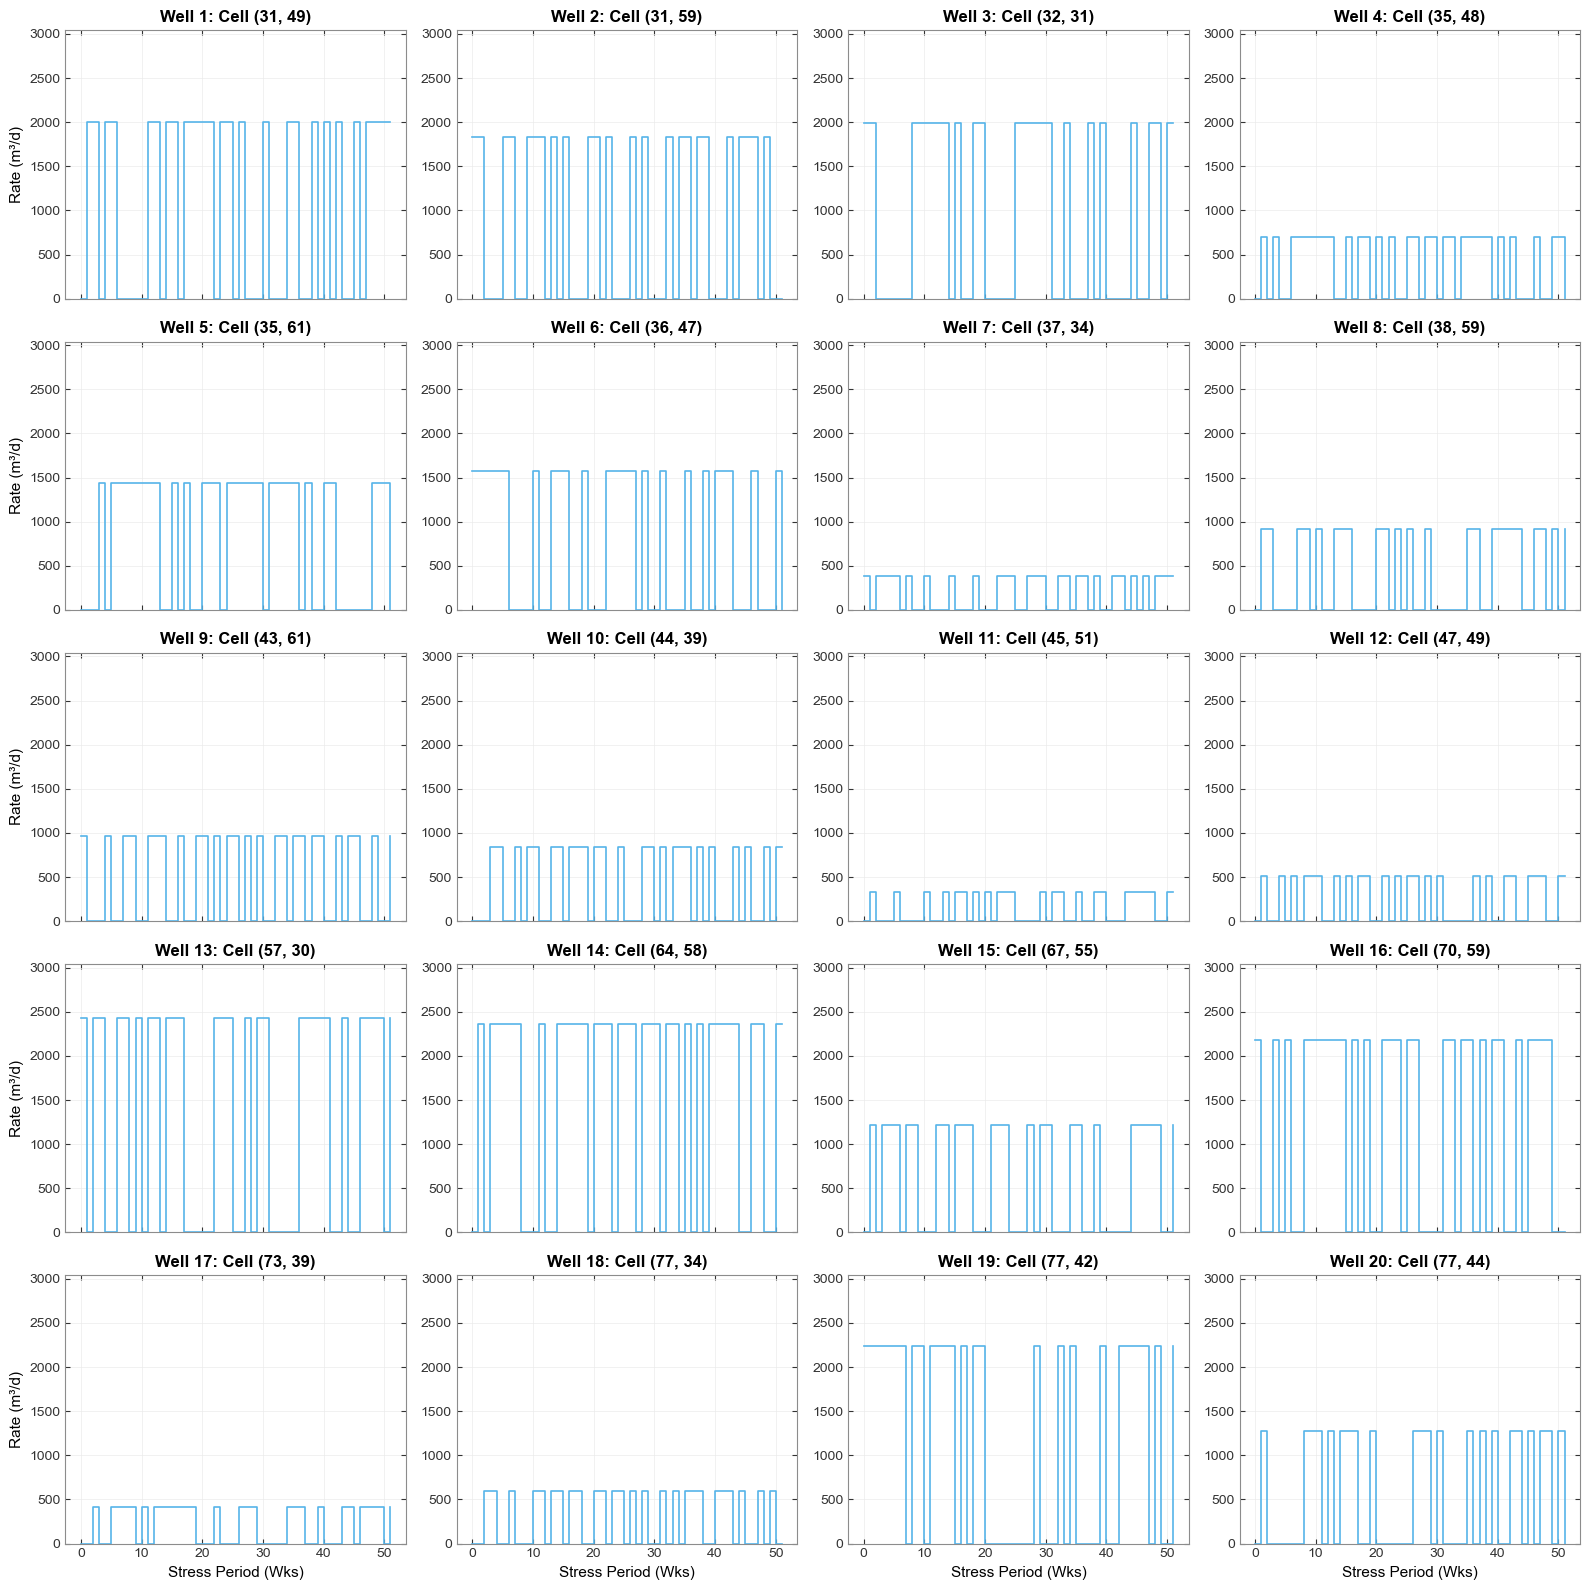

Report multi-panel operational matrix successfully written to: C:\Python\Personal\kfm-ms\codes\figures\numbasis_pumping_schedules.svg


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path

# =====================================================================
# 1. CORE PARAMETERS & PATH INITIALIZATION
# =====================================================================
num_root = "numbasis"

# Absolute workspace parameters pointing directly to your active directory branch
sims_data_path = Path(r"C:\Python\Personal\kfm-ms\codes\sims\numbasis")
figures_output_path = Path(r"C:\Python\Personal\kfm-ms\codes\figures")
figures_output_path.mkdir(parents=True, exist_ok=True)

# Standardized font scaling definitions for clean report blocks
size = 14  
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans']

truth_file = sims_data_path / "real" / "master_truth.csv"
if not truth_file.exists():
    raise FileNotFoundError(f"Missing schedule dataset at: {truth_file}")

df_q = pd.read_csv(truth_file)

# FIXED: Extract unique well locations strictly using 'r' and 'c' coordinate combinations
unique_wells = df_q[['r', 'c']].drop_duplicates().sort_values(['r', 'c']).reset_index(drop=True)
num_wells = len(unique_wells)

# 4 columns for clean vertical reporting layout
num_cols = 4
num_rows = (num_wells + (num_cols - 1)) // num_cols

# =====================================================================
# 2. GRID ARCHITECTURE INITIALIZATION
# =====================================================================
fig, axes = plt.subplots(num_rows, num_cols, figsize=(16, num_rows * 3.2), sharex=True)
axes = axes.flatten()

# Track maximum rate safely using the explicit 'q' string lookup
global_q_max = df_q['q'].max() if df_q['q'].max() > 0 else 100.0

# =====================================================================
# 3. COORDINATE-BASED STEPPED PROFILE ITERATION
# =====================================================================
for i, (_, row) in enumerate(unique_wells.iterrows()):
    ax = axes[i]
    r, c = int(row['r']), int(row['c'])
    
    ax.set_facecolor('white')
    ax.grid(True, color="#EBEBEB", linestyle="-", linewidth=0.5, zorder=0)
    
    for spine in ax.spines.values():
        spine.set_color('#8c8c8c')
        spine.set_linewidth(0.8)
    
    # FIXED: Filter rows explicitly using 'r' and 'c' keys and sort by stress period 'sp'
    well_mask = (df_q['r'] == r) & (df_q['c'] == c)
    truth_df_sorted = df_q[well_mask].sort_values("sp")
    
    truth_q = truth_df_sorted['q'].values
    stress_periods = truth_df_sorted['sp'].values
    
    # Plot true operational stepped physics curves
    ax.step(stress_periods, truth_q, where='post', color='#56B4E9', 
            linewidth=1.2, zorder=10)
    
    # Label panel using sequential index + coordinates to keep names clean
    ax.set_title(f"Well {i + 1}: Cell ({r}, {c})", fontsize=size-2, pad=6, fontweight='bold')
    ax.set_ylim(0, global_q_max * 1.25)
    
    ax.tick_params(axis='both', which='major', direction='in', labelsize=size-4, colors='#333333', top=True, right=True)
    
    # Label stripping logic for multi-row report grids
    if i % num_cols == 0:
        ax.set_ylabel("Rate (m³/d)", fontsize=size-3, labelpad=4)
    if i >= (num_wells - num_cols):
        ax.set_xlabel("Stress Period (Wks)", fontsize=size-3, labelpad=4)

# Delete unpopulated hanging axes plots if any remain
for j in range(num_wells, len(axes)):
    fig.delaxes(axes[j])

# =====================================================================
# 4. FILE VECTOR SAVE EXPORT
# =====================================================================
plt.tight_layout()
save_name = figures_output_path / f"{num_root}_pumping_schedules.svg"
plt.savefig(save_name, dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved to: {save_name}")

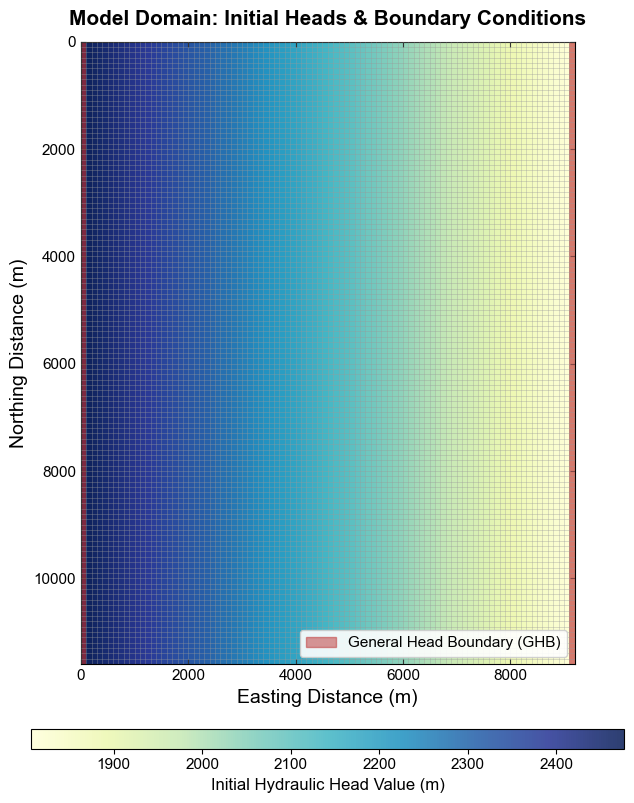

Report-ready IC/BC setup figure exported directly to: C:\Python\Personal\kfm-ms\codes\figures\numbasis_domain_icbc_setup.svg


In [ ]:
import os
from pathlib import Path
import flopy
import numpy as np
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as patches

# =====================================================================
# 1. PARAMETERS & PATH SPECIFICATIONS (REPORT ALIGNED)
# =====================================================================
num_root = "numbasis"

# Structural grid dimension parameters matching your core forward setup
cell_dim = 100.0  # meters per grid cell block
nrow, ncol = 116, 92
lx_m, ly_m = ncol * cell_dim, nrow * cell_dim

figures_output_path = Path(r"C:\Python\Personal\kfm-ms\codes\figures")
figures_output_path.mkdir(parents=True, exist_ok=True)

# Define report standard layout sizing constants
size = 14 
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans']

# --- EXPECTED INPUT VARIABLES ASSUMPTION TRACKING ---
# Assumes 'gwf' object and 'root' string are loaded and active in your workspace.
# If testing completely independently, uncomment the model loader lines below:
# results_path = Path("..") / "results"
# sim_real = flopy.mf6.MFSimulation.load(sim_ws=str(results_path / "baseline"), verbosity_level=0)
# gwf = sim_real.get_model("baseline")

# =====================================================================
# 2. CANVAS PLOT SETUP & MULTI-LAYER RENDER
# =====================================================================
# Reduced canvas size to keep document spacing tight
fig, ax = plt.subplots(1, 1, figsize=(9, 10.5))
ax.set_facecolor('white')

# Initialize MapView tracking model layout parameters
mapview = flopy.plot.PlotMapView(model=gwf, ax=ax, layer=0)

# Pull initial heads and active domain index matrices
strt_array = gwf.ic.strt.get_data()[0, :, :]
idomain_array = gwf.dis.idomain.get_data()[0, :, :]

# Compute data boundaries exclusively across active grid nodes (idomain != 0)
active_heads = strt_array[idomain_array != 0]
dynamic_vmin = active_heads.min()
dynamic_vmax = active_heads.max()

# Mask inactive domain areas cleanly
strt_masked = np.ma.masked_where(idomain_array == 0, strt_array)
quadmesh = mapview.plot_array(
    strt_masked, 
    cmap="YlGnBu", 
    vmin=dynamic_vmin, 
    vmax=dynamic_vmax, 
    zorder=0, 
    alpha=0.85
)

# Overlay sharp structural cell boundary grid lines matching side-by-side maps
mapview.plot_grid(colors="#999999", linewidths=0.5, zorder=4, alpha=0.5)

legend_elements = []

# Map No-Flow boundary exceptions
if np.any(idomain_array == 0):
    mapview.plot_ibound(color_noflow='lightgray', zorder=1)
    legend_elements.append(patches.Patch(facecolor='lightgray', edgecolor='#999999', hatch="//", lw=0.5, label='No-Flow Zone'))

# Overlay GHB boundaries using your report-defined blue tracking theme
has_ghb = any(p.package_type == "ghb" for p in gwf.packagelist)
if has_ghb:
    # Changed boundary highlight color to #3182bd to match side-by-side layout standards
    mapview.plot_bc(name="GHB", color="#bd3131", alpha=0.4, zorder=2)
    legend_elements.append(patches.Patch(facecolor='#bd3131', alpha=0.5, edgecolor='#bd3131', label='General Head Boundary (GHB)'))

# =====================================================================
# 3. CRITICAL CLIPPING AND ASPECT RATIO CORRECTIONS
# =====================================================================
# LOCKS SCALE TO TRUE METERS AND PACKS PLOT FRAMES TIGHTLY WITHOUT VERTICAL/HORIZONTAL WHITE SPACE
ax.set_xlim(0, lx_m)
ax.set_ylim(ly_m, 0) # Invert axis properly to preserve row orientation
ax.set_aspect('equal', adjustable='box')

ax.set_xlabel("Easting Distance (m)", fontsize=size)
ax.set_ylabel("Northing Distance (m)", fontsize=size)
ax.set_title("Model Domain: Initial Heads & Boundary Conditions", fontsize=size+1, pad=12, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=size-3, direction='in', top=True, right=True)

# =====================================================================
# 4. COLORBAR AND INLINE LEGEND COUPLING
# =====================================================================
# Positioned horizontally below the chart to conserve report space margins
cbar = fig.colorbar(quadmesh, ax=ax, orientation='horizontal', shrink=0.85, aspect=30, pad=0.08)
cbar.set_label("Initial Hydraulic Head Value (m)", fontsize=size-2, fontweight='medium')
cbar.ax.tick_params(labelsize=size-3)
cbar.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))

if legend_elements:
    ax.legend(
        handles=legend_elements, 
        loc='lower right', 
        ncol=1, 
        facecolor='white', 
        edgecolor='#cccccc', 
        framealpha=0.9, 
        fontsize=size-3
    )

# =====================================================================
# 5. DOCUMENT REPORT FORMAT EXPORT
# =====================================================================
save_name = figures_output_path / f"{num_root}_domain_icbc_setup.svg"
plt.savefig(save_name, dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved to: {save_name}")

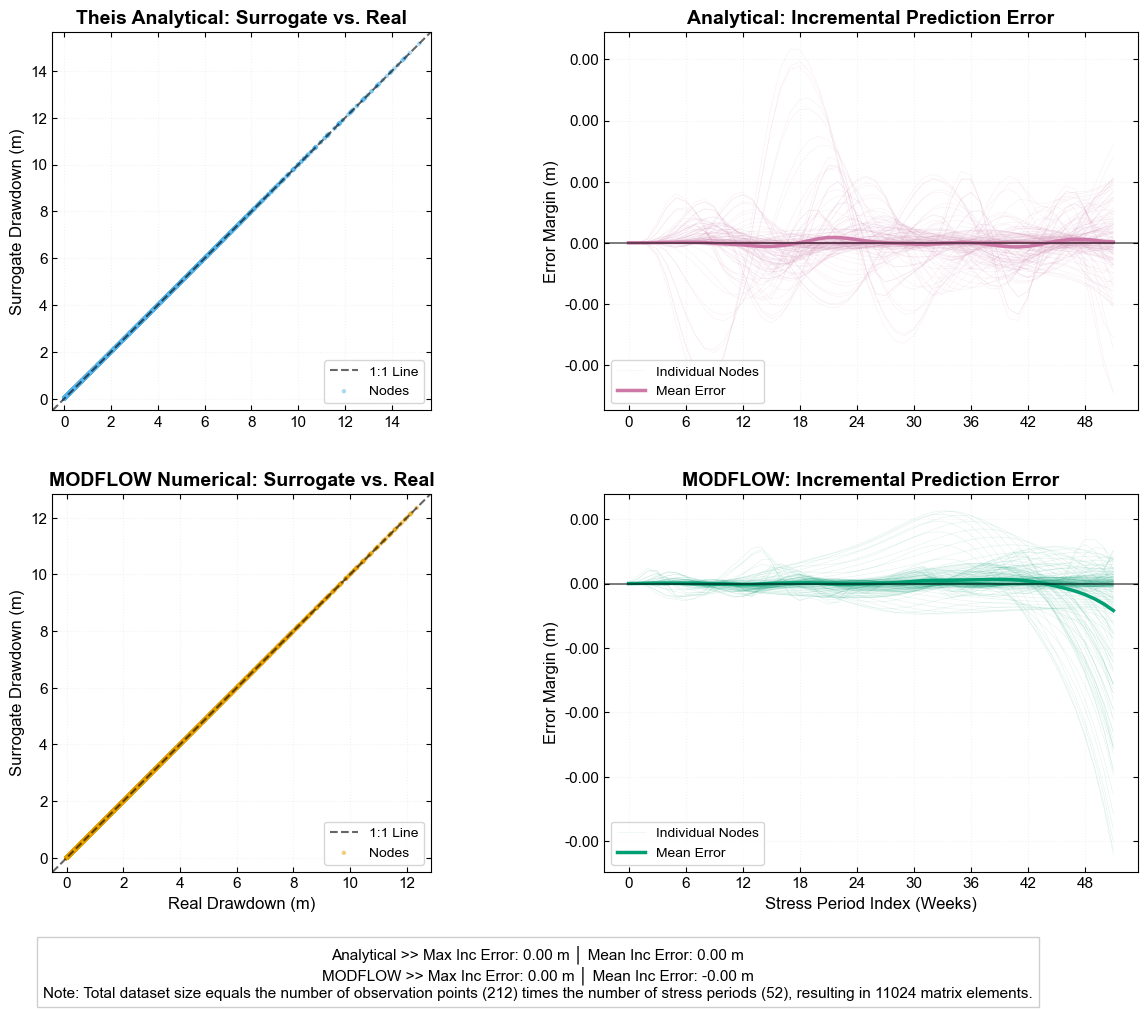

Saved to: C:\Python\Personal\kfm-ms\codes\figures\stacked_inversion_comparison.svg


In [23]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# =====================================================================
# 1. CORE CONFIGURATION & PATH MAPPING
# =====================================================================
num_root = "numbasis"
ana_root = "anabasis"

results_path = Path("..") / "results"
figures_output_path = Path(r"C:\Python\Personal\kfm-ms\codes\figures")
figures_output_path.mkdir(parents=True, exist_ok=True)

# --- LOAD DATASETS ---
num_real = pd.read_csv(results_path / f"{num_root}_target_drawdown.csv", index_col=0)
num_surr = pd.read_csv(results_path / f"{num_root}_surrogate_match.csv", index_col=0)

try:
    ana_real = pd.read_csv(results_path / f"{ana_root}_target_drawdown.csv", index_col=0)
    ana_surr = pd.read_csv(results_path / f"{ana_root}_surrogate_match.csv", index_col=0)
    has_analytical = True
except FileNotFoundError:
    print("Warning: Analytical data missing. Displaying numerical profiles only.")
    has_analytical = False

# --- READ OPTIMIZATION METADATA DIAGNOSTICS ---
num_iters = "N/A"
ana_iters = "N/A"

num_meta_path = results_path / f"{num_root}_optimization_metadata.csv"
if num_meta_path.exists():
    num_meta_df = pd.read_csv(num_meta_path)
    num_iters = int(num_meta_df.loc[0, "iterations"])

if has_analytical:
    ana_meta_path = results_path / f"{ana_root}_optimization_metadata.csv"
    if ana_meta_path.exists():
        ana_meta_df = pd.read_csv(ana_meta_path)
        ana_iters = int(ana_meta_df.loc[0, "iterations"])

# =====================================================================
# 2. PLOT CANVAS INITIALIZATION (COMPACT REPORT PROFILE)
# =====================================================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans']

# Tight padding configuration for professional documentation insertion
fig, axs = plt.subplots(2, 2, figsize=(15, 10.5))
plt.subplots_adjust(wspace=0.18, hspace=0.22, bottom=0.14, top=0.94)

size = 14 

def format_axes(ax):
    ax.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=size-3)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(True, alpha=0.15, linestyle=':')

# =====================================================================
# ROW 1: THEIS ANALYTICAL MODEL ANALYSIS (TOP ROW)
# =====================================================================
if has_analytical:
    ana_real_inc = ana_real.diff().fillna(ana_real.iloc[0])
    ana_surr_inc = ana_surr.diff().fillna(ana_surr.iloc[0])
    ana_err_df = ana_real_inc - ana_surr_inc
    ana_err_mean = ana_err_df.mean(axis=1)

    # Axis 1,1: 1:1 Cloud (Analytical)
    ana_flat_real = ana_real.values.flatten()
    ana_flat_surr = ana_surr.values.flatten()
    lims_ana = (min(ana_flat_real.min(), ana_flat_surr.min()) - 0.5, max(ana_flat_real.max(), ana_flat_surr.max()) + 0.5)

    axs[0, 0].set_xlim(lims_ana)
    axs[0, 0].set_ylim(lims_ana)
    axs[0, 0].set_aspect('equal', adjustable='box')
    axs[0, 0].plot(lims_ana, lims_ana, color="black", alpha=0.6, linestyle='--', lw=1.5, label='1:1 Line')
    axs[0, 0].scatter(ana_flat_real, ana_flat_surr, color='#56B4E9', s=10, alpha=0.5, edgecolors='none', label='Nodes')
    axs[0, 0].set_title("Theis Analytical: Surrogate vs. Real", fontsize=size, pad=6, fontweight='bold')
    axs[0, 0].set_ylabel("Surrogate Drawdown (m)", fontsize=size-2)
    axs[0, 0].legend(loc='lower right', fontsize=size-4, framealpha=0.8)

    # Axis 1,2: Incremental Errors (Analytical)
    for i, col in enumerate(ana_err_df.columns):
        lbl = 'Individual Nodes' if i == 0 else ""
        axs[0, 1].plot(ana_err_df.index, ana_err_df[col], color='#CC79A7', alpha=0.12, lw=0.4, label=lbl)
    axs[0, 1].plot(ana_err_mean.index, ana_err_mean, color='#CC79A7', lw=2.5, label='Mean Error')
    axs[0, 1].axhline(0, color='black', lw=1.2, alpha=0.6)
    axs[0, 1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    axs[0, 1].set_title("Analytical: Incremental Prediction Error", fontsize=size, pad=6, fontweight='bold')
    axs[0, 1].set_ylabel("Error Margin (m)", fontsize=size-2)
    axs[0, 1].legend(loc='lower left', fontsize=size-4, framealpha=0.8)

# =====================================================================
# ROW 2: MODFLOW NUMERICAL MODEL ANALYSIS (BOTTOM ROW)
# =====================================================================
num_real_inc = num_real.diff().fillna(num_real.iloc[0])
num_surr_inc = num_surr.diff().fillna(num_surr.iloc[0])
num_err_df = num_real_inc - num_surr_inc
num_err_mean = num_err_df.mean(axis=1)

# Axis 2,1: 1:1 Cloud (Numerical)
num_flat_real = num_real.values.flatten()
num_flat_surr = num_surr.values.flatten()
lims_num = (min(num_flat_real.min(), num_flat_surr.min()) - 0.5, max(num_flat_real.max(), num_flat_surr.max()) + 0.5)

axs[1, 0].set_xlim(lims_num)
axs[1, 0].set_ylim(lims_num)
axs[1, 0].set_aspect('equal', adjustable='box')
axs[1, 0].plot(lims_num, lims_num, color="black", alpha=0.6, linestyle='--', lw=1.5, label='1:1 Line')
axs[1, 0].scatter(num_flat_real, num_flat_surr, color='#E69F00', s=10, alpha=0.5, edgecolors='none', label='Nodes')
axs[1, 0].set_title("MODFLOW Numerical: Surrogate vs. Real", fontsize=size, pad=6, fontweight='bold')
axs[1, 0].set_ylabel("Surrogate Drawdown (m)", fontsize=size-2)
axs[1, 0].set_xlabel("Real Drawdown (m)", fontsize=size-2)
axs[1, 0].legend(loc='lower right', fontsize=size-4, framealpha=0.8)

# Axis 2,2: Incremental Errors (Numerical)
for i, col in enumerate(num_err_df.columns):
    lbl = 'Individual Nodes' if i == 0 else ""
    axs[1, 1].plot(num_err_df.index, num_err_df[col], color='#009E73', alpha=0.12, lw=0.4, label=lbl)
axs[1, 1].plot(num_err_mean.index, num_err_mean, color='#009E73', lw=2.5, label='Mean Error')
axs[1, 1].axhline(0, color='black', lw=1.2, alpha=0.6)
axs[1, 1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
axs[1, 1].set_title("MODFLOW: Incremental Prediction Error", fontsize=size, pad=6, fontweight='bold')
axs[1, 1].set_ylabel("Error Margin (m)", fontsize=size-2)
axs[1, 1].set_xlabel("Stress Period Index (Weeks)", fontsize=size-2)
axs[1, 1].legend(loc='lower left', fontsize=size-4, framealpha=0.8)

# Axis formatting polish
for row in axs:
    for ax in row:
        format_axes(ax)

# =====================================================================
# 3. REPORT FOOTER GENERATION (SIReN FRAMEWORK EDITION)
# =====================================================================
stats_text = (
    f"Analytical >> Max Inc Error: {ana_err_df.abs().max().max():.2f} m │ Mean Inc Error: {ana_err_df.mean().mean():.2f} m\n"
    f"MODFLOW >> Max Inc Error: {num_err_df.abs().max().max():.2f} m │ Mean Inc Error: {num_err_df.mean().mean():.2f} m\n"
    f"Note: Total dataset size equals the number of observation points ({num_real.shape[1]}) times the number of stress periods ({num_real.shape[0]}), resulting in {num_real.size} matrix elements."
)

fig.text(0.5, 0.02, stats_text, ha='center', fontsize=size-3, fontweight='medium',
         bbox=dict(facecolor='white', alpha=0.95, edgecolor='#cccccc', boxstyle='square,pad=0.4'))

save_name = figures_output_path / "stacked_inversion_comparison.svg"
plt.savefig(save_name, dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved to: {save_name}")